# Synthetic Data Regression — OAT Sampling Strategies

This notebook presents a reproducible experimental pipeline for evaluating **Online Active Testing (OAT)** strategies on three synthetic regression tasks.

We compare several sampling strategies for estimating model performance under a constrained annotation budget: Uniform sampling, OAT (1st moment), OAT (2nd moment), and Oracle strategy. Through sufficient repetition, this notebook helps visualise the unbiased characteristics of the baseline, OAT strategies, and the oracle, as well as the resulting variance.

## Experimental Setting

- Dataset: `Quadratic`, `GPprior`, `Sinusoidal`
- Model: Linear regression or Gaussian Process
- Surrogate model: Gaussian Process
- Evaluation metric: Mean squared error


In [1]:
import os
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

# Import libraries

In [2]:
# Machine learning library
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# For online active testing
from OAT.sampling_regression import compute_expected_squared_loss_regression_MSE, compute_expected_loss_regression_MSE
from OAT.OAT import oat_estimate, run_adaptive_selection

#Dataset generation and surrogate GP with third and fourth moment prediction
from dataset.dataset import generate_QuadraticDatasetForLinReg, generate_NonuniSin, generate_GaussianPrior
from models.GP import MomentGPRegressor


# Utils
from utils.per_sample_loss_function import per_sample_mse
from utils.Historic import Historic
from utils.utils import cummean

In [3]:
#Experiments configuration

kernel = Matern(length_scale=1.0, nu=1.5) 
config_exp = {
    "Quadratic": {
        'dataset': generate_QuadraticDatasetForLinReg, 
        'model_main':LinearRegression(),
        'model_aux': MomentGPRegressor(kernel=kernel, alpha=1e-6, optimizer=None),
        },
    "GPprior": {
        'dataset': generate_GaussianPrior, 
        'model_main': GaussianProcessRegressor(kernel=kernel, alpha=1e-6, optimizer=None),
        'model_aux': MomentGPRegressor(kernel=kernel, alpha=1e-6, optimizer=None),
        },
    "Sinusoidal": {
        'dataset': generate_NonuniSin, 
        'model_main': GaussianProcessRegressor(kernel=kernel, alpha=1e-6, optimizer=None),
        'model_aux': MomentGPRegressor(kernel=kernel, alpha=1e-6, optimizer=None),
        }
}

# Experimental Configuration

We define the hyperparameters of the OAT method on the regression datasets. `dataset` is the type of dataset we want to generate (`Quadratic`, `GPprior`, `Sinusoidal`). `nb_repet` is the number of repetitions for test via OAT. We generate `nb_points` and train the model using `train_size`. The model is then evaluated on a stream of `T_stream` points with a budget of `budget`. 

In [4]:
random_seed = 42
#Hyperparameters
dataset = "Quadratic"
nb_repet = 100

##Dataset generation
nb_points = 200
train_size = 20

##OAT hyperparamet
T_stream = nb_points - train_size
budget = 30

#Create folder to save results
save_dir = 'results/regression/'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Dataset generation and model training.
We additionally compute the per-sample loss of the points remaining in the stream and print the risk that we want to estimate.


In [5]:
#Dataset Generation
X,y = config_exp[dataset]['dataset'](nb_points)
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=train_size, random_state=random_seed)

#Main model to evaluate
model_main = config_exp[dataset]['model_main']
model_main.fit(X_train, y_train)

#Compute per sample losses in the stream
losses = per_sample_mse(model_main, X_test, y_test)
true_loss = np.mean(losses)

print("Model's risk", true_loss)

Model's risk 0.0055870677730063415


# Surrogate model
The auxiliary model here is a Gaussian Process initialised on the train dataset. The class `MomentGPRegressor` is the `scikit-learn` `GaussianProcessRegressor` with an additional function to predict the third and fourth moment of the predictions. We additionally show how we compute the first and second moment of the loss given the model to evaluate, the main model and samples.



In [6]:
#Auxialiary model pi
model_aux = config_exp[dataset]['model_aux']
model_aux.fit(X_train, y_train)

#Compute per 1st moment and second moment of the loss
MSE_1stmoment = compute_expected_loss_regression_MSE(model_main, model_aux, X_test)
MSE_2ndmoment = compute_expected_squared_loss_regression_MSE(model_main, model_aux, X_test)


# Sampling Strategies
We compare the four strategies presented in the article:
- Uniform: sampling points uniformly according to the budget $\beta_t=n_B/T$.
- Oracle: sampling points proportionally to the actual loss $L(\theta,x,y)$
- OAT 1st-moment: sampling points proportionally to the 1st moment of the loss given by the surrogate model $\mathbb{E}_\pi[L(\theta,x,y)]$.
- OAT 2nd-moment: sampling points proportionally to the square root of the 2nd moment of the loss $\sqrt{\mathbb{E}_\pi[L(\theta,x,y)^2]}$.

`Historic` class help storing experiments results.

In [7]:

STRATEGIES_CONFIG = {
    "Uniform":           {"adaptive": False, "metric": None, "fixed_beta": budget/T_stream},
    "Oracle":            {"adaptive": False, "metric": losses, "fixed_beta": None},
    "OAT 1st-moment":    {"adaptive": True,  "metric": "MSE_1stmoment", "fixed_beta": None},#Adaptive IS 1st moment strategy
    "OAT 2nd-moment":    {"adaptive": True,  "metric": "MSE_2ndmoment", "fixed_beta": None},#Adaptive IS 2nd moment strategy
}


# Initialize history objects in a dictionary
histories = {name: Historic(name, T_stream, budget, nb_repet) for name in STRATEGIES_CONFIG}


# OAT Streaming Procedure
At each iteration, a permutation is sampled to introduce randomness in the stream.

In [8]:


#Loop
for repet in tqdm(range(nb_repet)):
    # Shared permutation for this repetition
    permutation = np.random.permutation(len(X_test))[:T_stream]
    losses_permuted = losses[permutation]
    
    # We instantiate the GP once per repetition to be used by all adaptive strategies
    kernel = Matern(length_scale=1.0, nu=1.5)
    model_aux = MomentGPRegressor(kernel=kernel, alpha=1e-6, optimizer=None)
    
    for name, config in STRATEGIES_CONFIG.items():
        if config["adaptive"]:
                # Adaptive Strategy: Calls the complex run_adaptive_selection logic
                selection, p_selection = run_adaptive_selection(
                    model_main, model_aux, X_train, y_train, X_test, y_test, 
                    permutation, T_stream, budget, config["metric"]
                )
        else:
            # Non-Adaptive Strategy
            if config["fixed_beta"] is not None:
                p_selection = np.ones(T_stream) * config["fixed_beta"]
            else:
                # IS Strategy: beta = metric / cummean(metric) * budget/T
                metric_vals = config["metric"][permutation]
                p_selection = (metric_vals / cummean(metric_vals)) * (budget / T_stream)
                p_selection = np.minimum(p_selection, 1.0)
            
            # Generate selection mask based on the probabilities
            selection = np.random.uniform(size=T_stream) < p_selection
        
        histories[name].update(
            scores = oat_estimate(losses_permuted, selection, p_selection, T_stream),
            selection = selection,
            permutation = permutation,
            probabilities = p_selection,
            run_id = repet
        )

#Save and transform data to DataFrame
df_dict = {}
for name, _ in STRATEGIES_CONFIG.items():
    histories[name].save_to_csv(direction=save_dir) 
    df_dict[name] = histories[name].to_dataframe()

  0%|          | 0/100 [00:00<?, ?it/s]

Data saved to: results/regression/Uniform_100_180_30.csv
Data saved to: results/regression/Oracle_100_180_30.csv
Data saved to: results/regression/OAT 1st-moment_100_180_30.csv
Data saved to: results/regression/OAT 2nd-moment_100_180_30.csv


# Visualisation


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from utils_visu import *

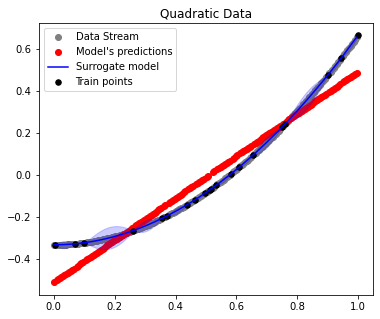

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(6, 5))
X_plot = np.linspace(X_test.min(), X_test.max(), 1000).reshape(-1, 1)

#Auxialiary model pi
model_aux = config_exp[dataset]['model_aux']
model_aux.fit(X_train, y_train)
mean_gp, std_gp = model_aux.predict(X_plot, return_std=True)


plt.scatter(X_test,y_test, c='grey', label = 'Data Stream')
plt.scatter(X_test, model_main.predict(X_test), label = "Model's predictions", c='r')
plot_gp(axes, mean_gp, std_gp, dataset + " Data",  min_x=X_test.min(), max_x=X_test.max())
plt.scatter(X_train, y_train, color="black", s=30, label='Train points')

plt.legend()
plt.show()

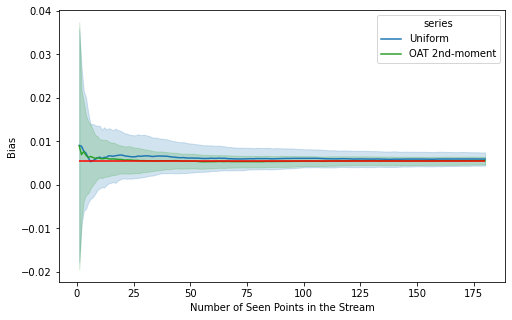

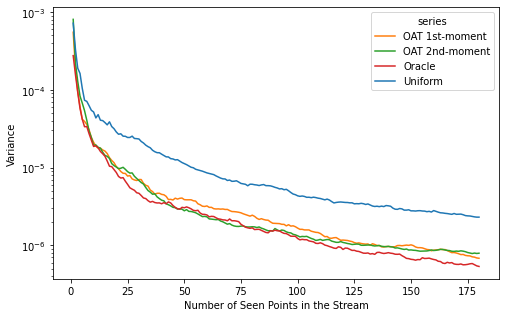

In [11]:
all_series = ['Uniform', 'OAT 1st-moment', 'OAT 2nd-moment', 'Oracle'] 
colors = sns.color_palette("tab10", len(all_series)) 
my_palette = dict(zip(all_series, colors))



#Plot biais
data_to_show = pd.concat([df_dict['Uniform'], df_dict['OAT 2nd-moment']])
plot_biais(data_to_show, true_loss, x='time', savefig=save_dir + "Bias", palette=my_palette)



#Plot Variance
data_to_show = pd.concat([df_dict['Uniform'], df_dict['OAT 1st-moment'], df_dict['OAT 2nd-moment'], df_dict['Oracle']])

plot_variance(data_to_show, true_loss, x='time', savefig=save_dir + "Variance", palette=my_palette)
